<a href="https://colab.research.google.com/github/SaiVarshitha-SV/AI-Powered-Fake-News-Detection-Using-Text-Classification-/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Fake News Detection Using Text Classification

---

In [1]:

# -----------------------------
# Import Basic Libraries
# -----------------------------
import pandas as pd
import numpy as np

# -----------------------------
# Visualization Libraries
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Text Processing Libraries
# -----------------------------
import re
import string

# -----------------------------
# Ignore Warnings
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# Machine Learning Libraries
# -----------------------------
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

# -----------------------------
# Evaluation Metrics
# -----------------------------
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# -----------------------------
# Natural Language Toolkit
# -----------------------------
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

print("="*60)
print("All required libraries imported successfully.")
print("="*60)

All required libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# ==========================================================
# STEP 1 : LOAD THE DATASET
# ==========================================================

# Project Folder Path
project_path = r"C:\B.Tech\Projects\IICT Project 1"

print("="*70)
print("Loading Dataset...")
print("="*70)

# Load Fake News Dataset
fake = pd.read_csv(project_path + r"\Fake.csv")

# Load True News Dataset
true = pd.read_csv(project_path + r"\True.csv")

print("Fake News Dataset Loaded Successfully.")
print("True News Dataset Loaded Successfully.")

print()

print("Number of Fake News Articles :", len(fake))
print("Number of True News Articles :", len(true))

print()

print("Both datasets are ready for analysis.")

Loading Dataset...
Fake News Dataset Loaded Successfully.
True News Dataset Loaded Successfully.

Number of Fake News Articles : 23481
Number of True News Articles : 21417

Both datasets are ready for analysis.


In [ ]:
# ==========================================================
# STEP 2 : EXPLORE THE DATASET
# ==========================================================

print("="*70)
print("FAKE NEWS DATASET")
print("="*70)

print("\nShape of Fake Dataset:")
print(fake.shape)

print("\nColumns:")
print(fake.columns.tolist())

print("\nFirst Five Records:")
display(fake.head())

print("\n")

print("="*70)
print("TRUE NEWS DATASET")
print("="*70)

print("\nShape of True Dataset:")
print(true.shape)

print("\nColumns:")
print(true.columns.tolist())

print("\nFirst Five Records:")
display(true.head())

FAKE NEWS DATASET

Shape of Fake Dataset:
(23481, 4)

Columns:
['title', 'text', 'subject', 'date']

First Five Records:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"




TRUE NEWS DATASET

Shape of True Dataset:
(21417, 4)

Columns:
['title', 'text', 'subject', 'date']

First Five Records:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
# ==========================================================
# STEP 3 : CREATE LABELS AND MERGE DATASET
# ==========================================================

print("="*70)
print("Assigning Labels")
print("="*70)

# Assign Labels
fake["label"] = 0
true["label"] = 1

print("Label Assigned")
print("0 --> Fake News")
print("1 --> True News")

print()

print("="*70)
print("Merging Datasets")
print("="*70)

# Merge datasets
data = pd.concat([fake, true], ignore_index=True)

print("Datasets merged successfully.")

print()

print("Merged Dataset Shape:")
print(data.shape)

print()

print("Last Column Added:")
print(data.columns.tolist())

print()

display(data.head())

Assigning Labels
Label Assigned
0 --> Fake News
1 --> True News

Merging Datasets
Datasets merged successfully.

Merged Dataset Shape:
(44898, 5)

Last Column Added:
['title', 'text', 'subject', 'date', 'label']



,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [ ]:
# ==========================================================
# STEP 4 : DATA INSPECTION
# ==========================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print("\nDataset Shape")
print(data.shape)

print("\n")

print("="*70)
print("COLUMN NAMES")
print("="*70)

print(data.columns.tolist())

print("\n")

print("="*70)
print("DATA TYPES")
print("="*70)

print(data.dtypes)

print("\n")

print("="*70)
print("MISSING VALUES")
print("="*70)

print(data.isnull().sum())

print("\n")

print("="*70)
print("DUPLICATE RECORDS")
print("="*70)

print("Total Duplicate Rows :", data.duplicated().sum())

DATASET INFORMATION

Dataset Shape
(44898, 5)


COLUMN NAMES
['title', 'text', 'subject', 'date', 'label']


DATA TYPES
title      object
text       object
subject    object
date       object
label       int64
dtype: object


MISSING VALUES
title      0
text       0
subject    0
date       0
label      0
dtype: int64


DUPLICATE RECORDS
Total Duplicate Rows : 209


In [ ]:
# ==========================================================
# STEP 5 : CLEAN THE DATASET
# ==========================================================

print("="*70)
print("DATA CLEANING")
print("="*70)

# Remove duplicate records
duplicate_rows = data.duplicated().sum()

data.drop_duplicates(inplace=True)

print(f"Duplicate Rows Removed : {duplicate_rows}")

# Remove missing values
missing_rows = data.isnull().sum().sum()

data.dropna(inplace=True)

print(f"Missing Values Removed : {missing_rows}")

# Reset Index
data.reset_index(drop=True, inplace=True)

print("\nCleaning Completed Successfully.")

print("\nFinal Dataset Shape :")
print(data.shape)

DATA CLEANING
Duplicate Rows Removed : 209
Missing Values Removed : 0

Cleaning Completed Successfully.

Final Dataset Shape :
(44689, 5)


In [ ]:
# ==========================================================
# STEP 6 : TEXT PREPROCESSING
# ==========================================================

print("=" * 70)
print("TEXT PREPROCESSING")
print("=" * 70)

# Display original text sample
print("\nOriginal News Article:\n")
print(data["text"].iloc[0][:500])

# Function to clean text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    text = " ".join(words)

    return text


print("\nCleaning all news articles...")

# Apply preprocessing
data["clean_text"] = data["text"].apply(clean_text)

print("Text preprocessing completed successfully.")

TEXT PREPROCESSING

Original News Article:

Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a gr

Cleaning all news articles...
Text preprocessing completed successfully.


In [ ]:
# ==========================================================
# STEP 7 : COMPARE ORIGINAL VS CLEANED TEXT
# ==========================================================

print("=" * 70)
print("ORIGINAL TEXT")
print("=" * 70)

print(data["text"].iloc[0][:800])

print("\n")

print("=" * 70)
print("CLEANED TEXT")
print("=" * 70)

print(data["clean_text"].iloc[0][:800])

ORIGINAL TEXT
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2


CLEANED TEXT
donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows strong

In [ ]:
# ==========================================================
# STEP 8 : FEATURE EXTRACTION USING TF-IDF
# ==========================================================

print("=" * 70)
print("TF-IDF FEATURE EXTRACTION")
print("=" * 70)

# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Transform text into numerical vectors
X = vectorizer.fit_transform(data["clean_text"])

# Target variable
y = data["label"]

print("\nTF-IDF Vectorization Completed Successfully.")

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Variable Shape:")
print(y.shape)

print("\nTotal Features Generated:", len(vectorizer.get_feature_names_out()))

TF-IDF FEATURE EXTRACTION

TF-IDF Vectorization Completed Successfully.

Feature Matrix Shape:
(44689, 5000)

Target Variable Shape:
(44689,)

Total Features Generated: 5000


In [ ]:
# ==========================================================
# STEP 9 : TRAIN-TEST SPLIT
# ==========================================================

print("=" * 70)
print("TRAIN - TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape :")
print(X_train.shape)

print("\nTesting Data Shape :")
print(X_test.shape)

print("\nTraining Labels :")
print(y_train.shape)

print("\nTesting Labels :")
print(y_test.shape)

TRAIN - TEST SPLIT

Training Data Shape :
(35751, 5000)

Testing Data Shape :
(8938, 5000)

Training Labels :
(35751,)

Testing Labels :
(8938,)


In [ ]:
# ==========================================================
# STEP 10 : TRAIN MACHINE LEARNING MODELS
# ==========================================================

print("=" * 70)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 70)

# Dictionary of Models
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Neural Network":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=300,
            random_state=42
        ),

    "Naive Bayes":
        MultinomialNB(),

    "Linear SVM":
        LinearSVC(random_state=42)

}

results = {}

trained_models = {}

for name, model in models.items():

    print("\n" + "="*70)
    print(f"Training {name}...")
    print("="*70)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    trained_models[name] = model

    print(f"{name} Trained Successfully")

    print(f"Accuracy : {accuracy:.4f}")

print("\n")
print("="*70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("="*70)

TRAINING MACHINE LEARNING MODELS

Training Logistic Regression...
Logistic Regression Trained Successfully
Accuracy : 0.9887

Training KNN...
KNN Trained Successfully
Accuracy : 0.6962

Training Random Forest...
Random Forest Trained Successfully
Accuracy : 0.9981

Training Neural Network...
Neural Network Trained Successfully
Accuracy : 0.9931

Training Naive Bayes...
Naive Bayes Trained Successfully
Accuracy : 0.9428

Training Linear SVM...
Linear SVM Trained Successfully
Accuracy : 0.9959


ALL MODELS TRAINED SUCCESSFULLY


In [ ]:
# ==========================================================
# STEP 11 : MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(

    results.items(),

    columns=["Model", "Accuracy"]

)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

print("="*70)
print("MODEL COMPARISON")
print("="*70)

display(results_df)

MODEL COMPARISON


,Model,Accuracy
2,Random Forest,0.998098
5,Linear SVM,0.995860
3,Neural Network,0.993063
0,Logistic Regression,0.988700
4,Naive Bayes,0.942828
1,KNN,0.696241


MODEL ACCURACY COMPARISON


,Model,Accuracy
2,Random Forest,0.998098
5,Linear SVM,0.995860
3,Neural Network,0.993063
0,Logistic Regression,0.988700
4,Naive Bayes,0.942828
1,KNN,0.696241


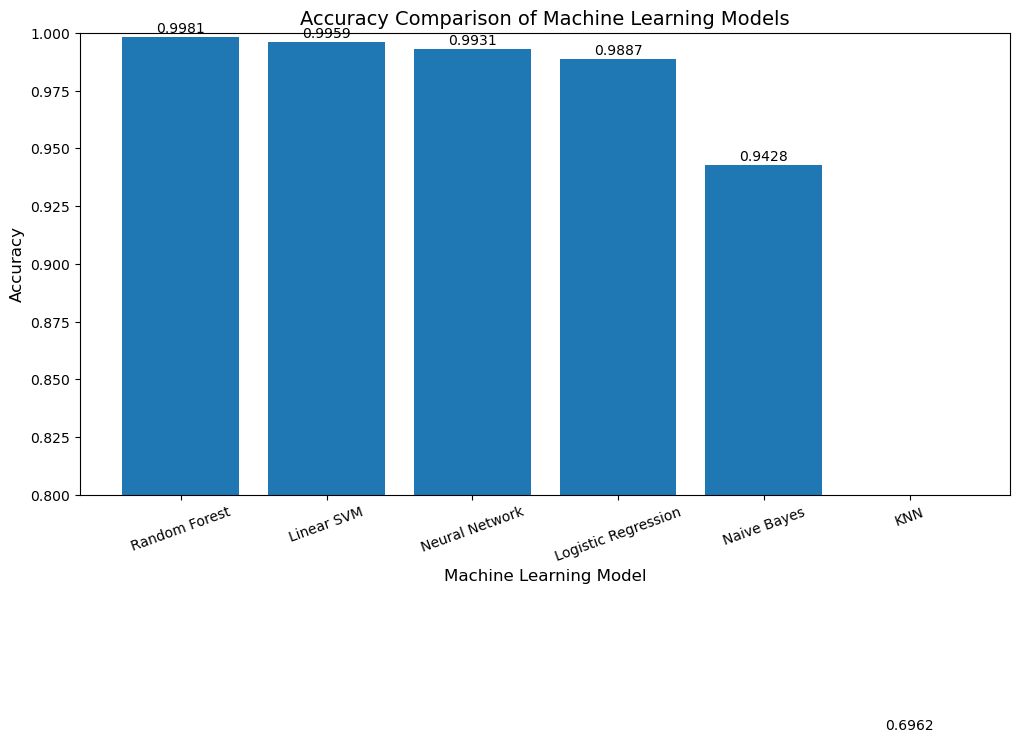

In [ ]:
# ==========================================================
# STEP 12 : ACCURACY COMPARISON GRAPH
# ==========================================================

print("=" * 70)
print("MODEL ACCURACY COMPARISON")
print("=" * 70)

# Display comparison table
display(results_df)

# Plot Accuracy Graph
plt.figure(figsize=(12,6))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Machine Learning Models", fontsize=14)

plt.xlabel("Machine Learning Model", fontsize=12)

plt.ylabel("Accuracy", fontsize=12)

plt.xticks(rotation=20)

plt.ylim(0.80,1.00)

for index,value in enumerate(results_df["Accuracy"]):
    plt.text(index,value+0.002,f"{value:.4f}",ha='center')

plt.show()

In [ ]:
# ==========================================================
# STEP 13 : CLASSIFICATION REPORTS
# ==========================================================

print("="*80)
print("CLASSIFICATION REPORTS")
print("="*80)

predictions = {}

for name, model in trained_models.items():

    print("\n")
    print("="*80)
    print(name.upper())
    print("="*80)

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    print(classification_report(y_test, y_pred))

CLASSIFICATION REPORTS


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



KNN
              precision    recall  f1-score   support

           0       0.64      0.97      0.77      4696
           1       0.92      0.39      0.55      4242

    accuracy                           0.70      8938
   macro avg       0.78      0.68      0.66      8938
weighted avg       0.77      0.70      0.67      8938



RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighte



Logistic Regression


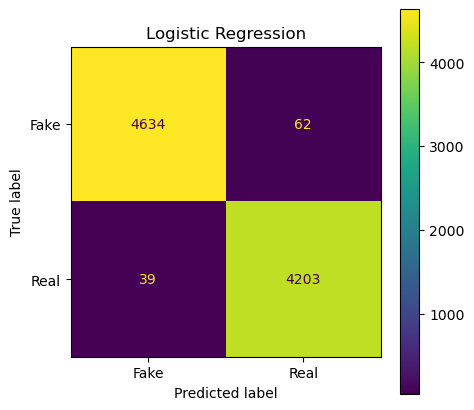



KNN


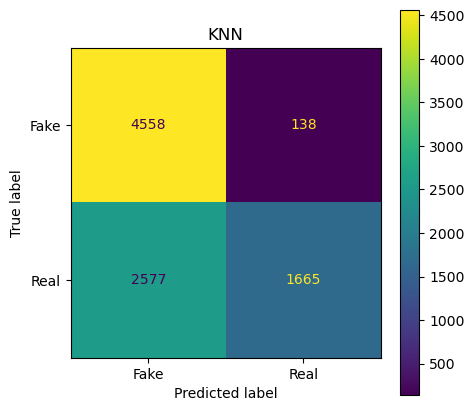



Random Forest


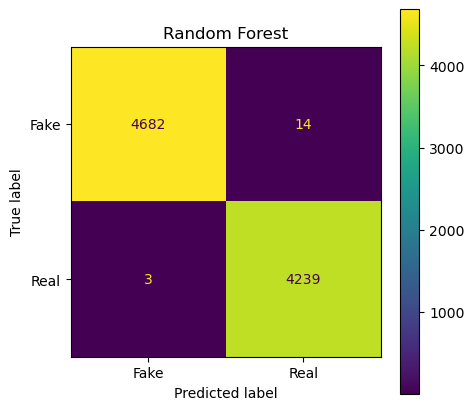



Neural Network


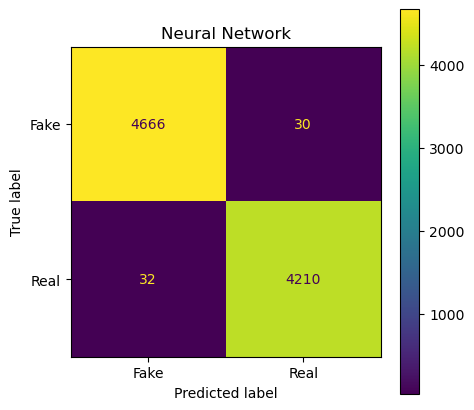



Naive Bayes


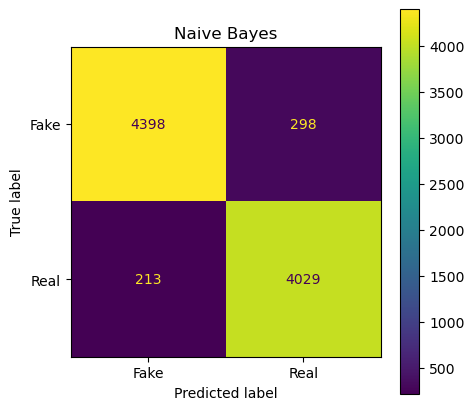



Linear SVM


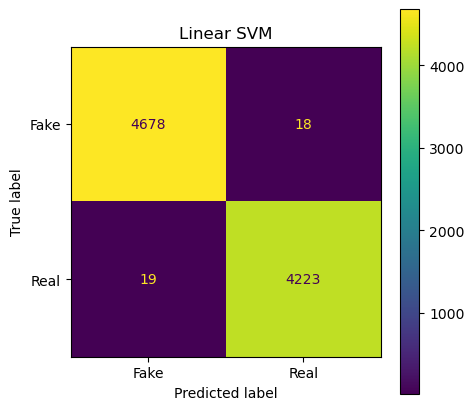

In [ ]:
# ==========================================================
# STEP 14 : CONFUSION MATRICES
# ==========================================================

for name, model in trained_models.items():

    print("\n")
    print("="*70)
    print(name)
    print("="*70)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Fake","Real"]
    )

    fig, ax = plt.subplots(figsize=(5,5))

    disp.plot(ax=ax)

    plt.title(name)

    plt.show()

In [ ]:
# ==========================================================
# STEP 15 : IDENTIFY THE BEST MODEL
# ==========================================================

print("=" * 70)
print("BEST MODEL IDENTIFICATION")
print("=" * 70)

# Find best model
best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print(f"\nBest Model       : {best_model_name}")
print(f"Testing Accuracy : {best_accuracy:.4f}")

# Retrieve the trained model
best_model = trained_models[best_model_name]

print("\nThe best-performing model has been selected successfully.")

BEST MODEL IDENTIFICATION

Best Model       : Random Forest
Testing Accuracy : 0.9981

The best-performing model has been selected successfully.


In [ ]:
# ==========================================================
# STEP 16 : CUSTOM NEWS PREDICTION
# ==========================================================

def predict_news(news_text):
    """
    Predict whether a news article is Fake or Real.
    """

    # Convert to lowercase
    news_text = news_text.lower()

    # Remove URLs
    news_text = re.sub(r'http\S+|www\S+|https\S+', '', news_text)

    # Remove HTML tags
    news_text = re.sub(r'<.*?>', '', news_text)

    # Remove punctuation
    news_text = news_text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    news_text = re.sub(r'\d+', '', news_text)

    # Remove extra spaces
    news_text = re.sub(r'\s+', ' ', news_text)

    # Remove stopwords
    words = news_text.split()
    words = [word for word in words if word not in stop_words]

    cleaned_text = " ".join(words)

    # Convert to TF-IDF
    transformed_text = vectorizer.transform([cleaned_text])

    # Predict
    prediction = best_model.predict(transformed_text)[0]

    print("\nPrediction Result")
    print("-" * 40)

    if prediction == 0:
        print("Fake News")
    else:
        print("Real News")

In [ ]:
# ==========================================================
# STEP 17 : TEST THE MODEL
# ==========================================================

sample_news = """
The Government announced a new education policy aimed at improving
digital learning infrastructure across public universities.
"""

predict_news(sample_news)


Prediction Result
----------------------------------------
Fake News
